In [49]:
# Import useufl libs
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ezpadova

In [50]:
# Load in the given data
data = pd.read_csv("mystery_gc.dat", names=["F606W", "F814W", "F606W_err", "F814W_err"], header=0, sep=' ')
data["color"] = data["F606W"] - data["F814W"]
data["color_err"] = np.sqrt(data["F606W_err"]**2 + data["F814W_err"]**2)

In [51]:
data.head()

,F606W,F814W,F606W_err,F814W_err,color,color_err
0,19.133,17.939,0.001,0.001,1.194,0.001414
1,18.969,18.064,0.004,0.004,0.905,0.005657
2,19.016,18.238,0.001,0.001,0.778,0.001414
3,18.853,18.377,0.001,0.001,0.476,0.001414
4,19.059,18.602,0.001,0.001,0.457,0.001414


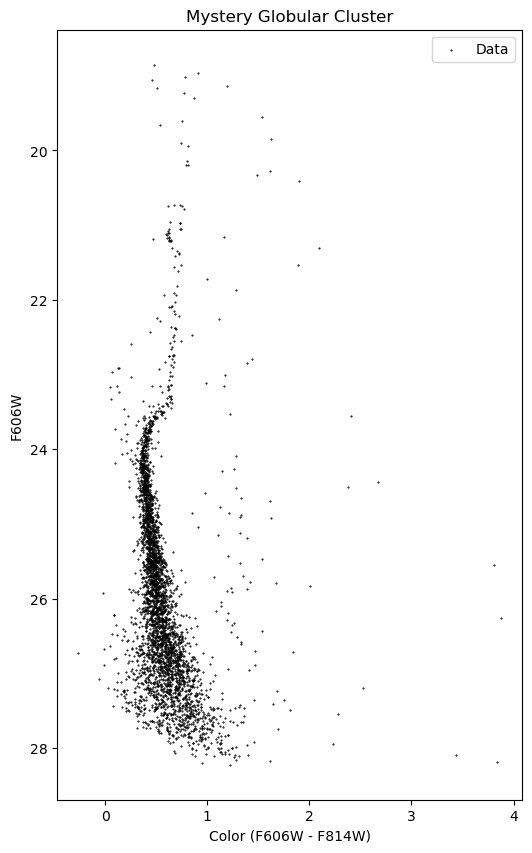

In [52]:
# 1. Create the figure object
fig = plt.figure(figsize=(6, 10))

# 2. Add an axes object to the figure
# (1, 1, 1) means: 1 row, 1 column, 1st plot
ax = fig.add_subplot(1, 1, 1)

# 3. Now you can use 'ax' just like before
ax.scatter(data["color"], data["F606W"], marker='.', color="black", s=1, label="Data")

# Standard CMD formatting
ax.set_xlabel("Color (F606W - F814W)")
ax.set_ylabel("F606W")
ax.invert_yaxis() 
ax.set_title("Mystery Globular Cluster")
ax.legend()

plt.show()

Querying http://stev.oapd.inaf.it/cgi-bin/cmd...
Retrieving data...


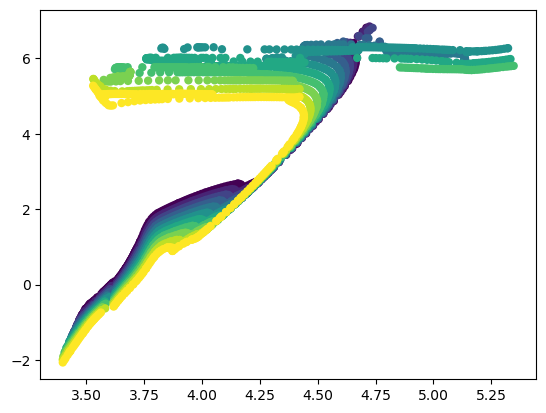

In [53]:
# Test ezpadova
r = ezpadova.get_isochrones(logage=(6, 7, 0.1), MH=(0, 0, 0), photsys_file='gaiaEDR3')
plt.scatter(r['logTe'], r['logL'], c=r['logAge'], edgecolor='None')
plt.show()

In [212]:
# Get some isochrones
ages = [np.log10(5e9), np.log10(6e9), 0.02] # [init, final, step] We think our globular cluster is old
MH = [-1.3, -1.1, 0.01]# [init, final, step] We think we will be metal poor. MH is [M/H] ~= [Fe/H]
test = ezpadova.get_isochrones(photsys_file='wfc3_202101_wide', logage=ages, MH=MH)

Querying http://stev.oapd.inaf.it/cgi-bin/cmd...
Retrieving data...


In [216]:
# Add distance
dist_kpc = 170
dist_pc = dist_kpc * 1e3 
distance_modulus = 5 * np.log10(dist_pc) - 5

# Calculate extinction for each filter
Av = 0.0 # Visual extinction in 'magnitudes of dust'
R_F606W = 0.92
R_F814W = 0.60

test["F606Wmag_app"] = test["F606Wmag"] + distance_modulus + (R_F606W * Av)
test["F814Wmag_app"] = test["F814Wmag"] + distance_modulus + (R_F814W * Av)
test["color_app"] = test["F606Wmag_app"] - test["F814Wmag_app"]

In [217]:
# Hide the stars which are unobservable
magLimit = 28
test["observable"] = (test["F606Wmag_app"] < magLimit) & (test["F814Wmag_app"] < magLimit)  
to_plot = test[test["observable"]]

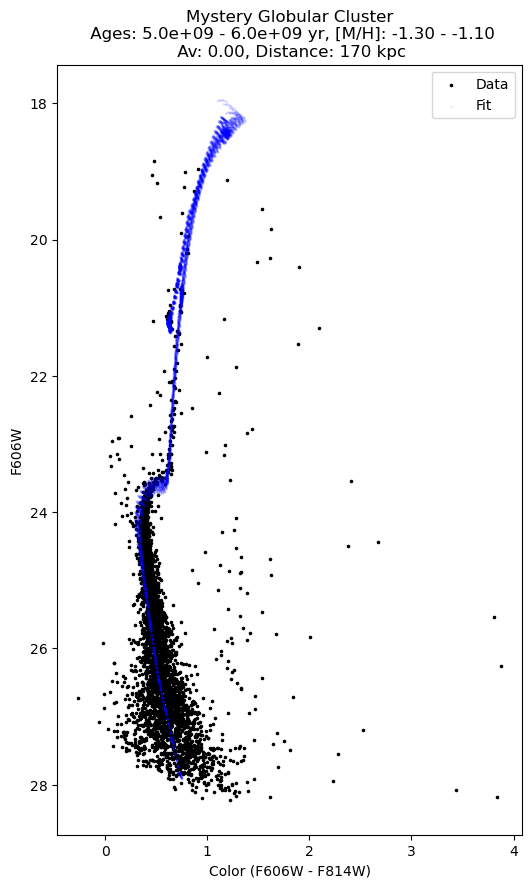

In [218]:
# 1. Create the figure object
fig = plt.figure(figsize=(6, 10))

# 2. Add an axes object to the figure
# (1, 1, 1) means: 1 row, 1 column, 1st plot
ax = fig.add_subplot(1, 1, 1)

# 3. Now you can use 'ax' just like before
ax.scatter(data["color"], data["F606W"], marker='.', color="black", s=10, label="Data")
ax.scatter(to_plot["color_app"], to_plot["F606Wmag_app"], marker='.', color="blue", s=1, alpha=0.1, label="Fit")

# Standard CMD formatting
ax.set_xlabel("Color (F606W - F814W)")
ax.set_ylabel("F606W")
ax.invert_yaxis() 
ax.set_title(f"Mystery Globular Cluster\n Ages: {10**ages[0]:.1e} - {10**ages[1]:.1e} yr, [M/H]: {MH[0]:.2f} - {MH[1]:.2f}\n Av: {Av:.2f}, Distance: {dist_kpc} kpc")
ax.legend()

plt.show()